# **Objective:** Build contingency tables in Python and visualize the relationship between two categorical variables.



In [1]:
import pandas as pd 
import numpy as np
import random
import matplotlib.pyplot as plt

* **Task 1: Universal (The Basics)**
  * *Instructions:* Generate a synthetic dataset of 100 people. Assign `Gender` and `Pet_Owner`. Make females slightly more likely to own pets. Build a 2x2 Two-Way Frequency Table using loops or `pandas.crosstab`.
  * *Acceptance Criteria:* A 2x2 matrix prints out showing the counts (Male/Yes, Male/No, Female/Yes, Female/No). Convert to Relative Frequency (percentages summing to 100%).


In [2]:

gender = ['Male','Female']
pet_own = ["Yes","No"]
n_people = 100

dct = {'Gender':[],
       'Pet_Owner':[]}

for n in range(n_people):
    dct['Gender'].append(random.choice(gender))
    if dct['Gender'][-1] == 'Female':
        dct['Pet_Owner'].append(random.choices(pet_own,weights=[0.60,0.40])[0])
    elif dct['Gender'][-1] == 'Male':
        dct['Pet_Owner'].append(random.choices(pet_own,weights=[0.5,0.5])[0])

In [3]:
df = pd.DataFrame(dct)
df.head()

,Gender,Pet_Owner
0,Female,Yes
1,Male,No
2,Female,Yes
3,Male,Yes
4,Female,No


In [4]:
df.value_counts()

Gender  Pet_Owner
Female  Yes          32
Male    No           27
        Yes          23
Female  No           18
Name: count, dtype: int64

In [5]:
pd.crosstab(df['Pet_Owner'],df['Gender'],normalize='columns')

Gender,Female,Male
Pet_Owner,,
No,0.36,0.54
Yes,0.64,0.46


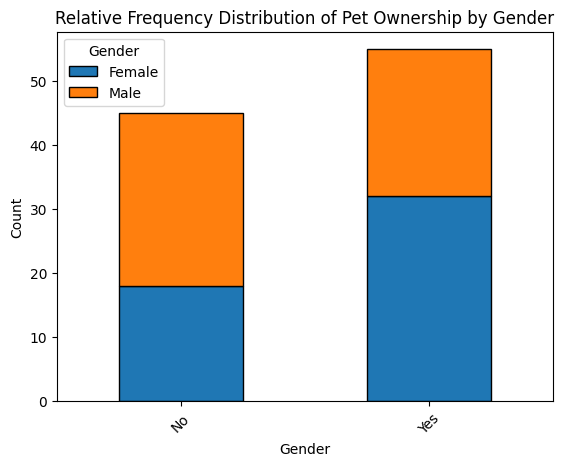

In [6]:
ct = pd.crosstab(df['Pet_Owner'],df['Gender'])
ct.plot(kind='bar',stacked=True,edgecolor='black')
plt.title('Relative Frequency Distribution of Pet Ownership by Gender')
plt.ylabel('Count')
plt.xlabel('Gender')
plt.xticks(rotation=45)
plt.show()

* **Task 2: Capstone (Antifraud Application)**
  * *Instructions:* Generate a dataset of 1,000 transactions. `Transaction_Location` (90% Local, 10% Int). `Is_Fraud` (Yes/No), with Int having higher fraud risk. Build the 2x2 frequency table.
  * *Acceptance Criteria:* The table outputs a 2x2 matrix with total counts. Convert to Relative Frequency Table (sums to 1.0).


In [9]:
dct_transactions = {
    'Transaction_Location':[],
    'Is_Fraud':[]
}

locations = ['Local','Int']
fraud = ['Yes','No']

n_transactions = 1000
for n in range(n_transactions):
    dct_transactions['Transaction_Location'].append(random.choices(locations,weights=[0.9,0.1])[0])
    if dct_transactions['Transaction_Location'][-1] == 'Int':
        dct_transactions['Is_Fraud'].append(random.choices(fraud,weights=[0.7,0.3])[0])
    elif dct_transactions['Transaction_Location'][-1] == 'Local':
        dct_transactions['Is_Fraud'].append(random.choices(fraud,weights=[0.3,0.7])[0])

df_transactions = pd.DataFrame(dct_transactions)

In [11]:
df_transactions.head()

,Transaction_Location,Is_Fraud
0,Local,Yes
1,Local,No
2,Local,Yes
3,Int,Yes
4,Local,No


In [12]:
df_transactions.value_counts()

Transaction_Location  Is_Fraud
Local                 No          651
                      Yes         257
Int                   Yes          68
                      No           24
Name: count, dtype: int64

In [16]:
pd.crosstab(df_transactions['Transaction_Location'],df_transactions['Is_Fraud'])

Is_Fraud,No,Yes
Transaction_Location,,
Int,24,68
Local,651,257


In [15]:
pd.crosstab(df_transactions['Transaction_Location'],df_transactions['Is_Fraud'],normalize='index')

Is_Fraud,No,Yes
Transaction_Location,,
Int,0.26087,0.73913
Local,0.71696,0.28304


* **Task 3: Hidden Concept (Visualizing Relationships)**
  * *Instructions:* Using the Antifraud table from Task 2, create a **Stacked Bar Chart** using `pandas.DataFrame.plot(kind='bar', stacked=True)`. The X-axis is Location, the bars are stacked with Fraud vs No Fraud proportions.
  * *Acceptance Criteria:* A stacked bar chart renders. You must normalize the data so the bars represent 100% proportions, allowing you to visually compare the fraud rate between Local and International.
  

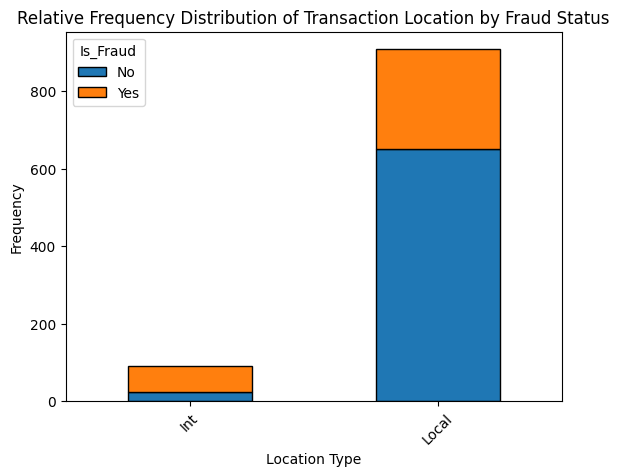

In [22]:
ct = pd.crosstab(df_transactions['Transaction_Location'],df_transactions['Is_Fraud'])
ct.plot(kind='bar',stacked=True,edgecolor='black')
plt.xlabel('Location Type')
plt.ylabel('Frequency')
plt.title('Relative Frequency Distribution of Transaction Location by Fraud Status')
plt.xticks(rotation=45)
plt.show()